Downloading and unzipping Dataset

In [ ]:
!wget -O dataset.zip "https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1003-CustTransPred.zip"

In [ ]:
!unzip -o dataset.zip -d dataset/

Archive:  dataset.zip
  inflating: dataset/Data/train(1).csv  


Importing  packages

In [ ]:
!pip3 install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00


In [ ]:
# hyperparameter tuner
!pip3 install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

# for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

# for scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

# for handling dimensionality complexity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# spliting data for training and testing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# performance
from sklearn.metrics import classification_report, roc_auc_score, make_scorer

# meta-model for stacking ensemble
from sklearn.linear_model import LogisticRegression

# base models
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# hyperparameter tuner
import optuna

# to check if gpu is available or not
import torch

import warnings
warnings.filterwarnings('ignore')

Importing dataset

In [ ]:
train = pd.read_csv('/content/dataset/Data/train(1).csv')

In [ ]:
train.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [ ]:
train.shape

(200000, 202)

Droping unnecessary column

In [ ]:
train.drop(columns=['ID_code'], inplace=True)
train.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


Checking duplicated values

In [ ]:
train.duplicated().sum()

np.int64(0)

Checking Null values

In [ ]:
train.isnull().values.sum()

np.int64(0)

Checking Unbalance in the target column

In [ ]:
train['target'].value_counts()

,count
target,
0,179902
1,20098


We can clearly see that the `target` column is highly unbalanced so we may need to use SMOTE or use non-linear/ensemble models

Checking memory usage

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 201 entries, target to var_199
dtypes: float64(200), int64(1)
memory usage: 306.7 MB


Checking summary of data

In [ ]:
train.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


Reducing dtype of independent variables to reduce memory usage with a harmless drop in standard deviation

In [ ]:
def reduce_column_dtype(df, col):
    col_max, col_min = df[col].max(), df[col].min()

    if pd.api.types.is_integer_dtype(df[col]):
        for dtype in [np.int8, np.int16, np.int32, np.int64]:
            if np.iinfo(dtype).min <= col_min and col_max <= np.iinfo(dtype).max:
                df[col] = df[col].astype(dtype)
                break
    else:
        for dtype in [np.float32, np.float64]:
            if np.finfo(dtype).min <= col_min and col_max <= np.finfo(dtype).max:
                df[col] = df[col].astype(dtype)
                break

    return df

In [ ]:
for col in train.select_dtypes(include=[np.number]).columns:
  train = reduce_column_dtype(train, col)

We can also reduce the dtype of independent variable to float16 but it losses the precision so much that it made the standard deviation zero so to solve that issue we had to reduce the dtype to float32 instead.

Reduced memory usage from 300MB to 150MB


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 201 entries, target to var_199
dtypes: float32(200), int8(1)
memory usage: 152.8 MB


We can see that standard deviation has dropped by an average value of 0.000055

In [ ]:
train.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715190,6.796530,11.078333,-5.065317,5.408949,16.545851,0.284162,...,3.234439,7.438409,1.927838,3.331773,17.993788,-0.142088,2.303335,8.908157,15.870723,-3.326537
std,0.300653,3.039990,4.049967,2.640832,2.043276,1.623114,7.863115,0.866585,3.418009,3.332576,...,4.559854,3.023208,1.478388,3.991934,3.135113,1.429341,5.454274,0.921603,3.010892,10.437832
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562599,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852798
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064724,4.836800
max,1.000000,20.315001,10.376800,19.353001,13.188300,16.671400,17.251600,8.447700,27.691799,10.151300,...,18.440901,16.716499,8.402400,18.281799,27.928801,4.272900,18.321501,12.000400,26.079100,28.500700


Plotting heatmap to check correlation

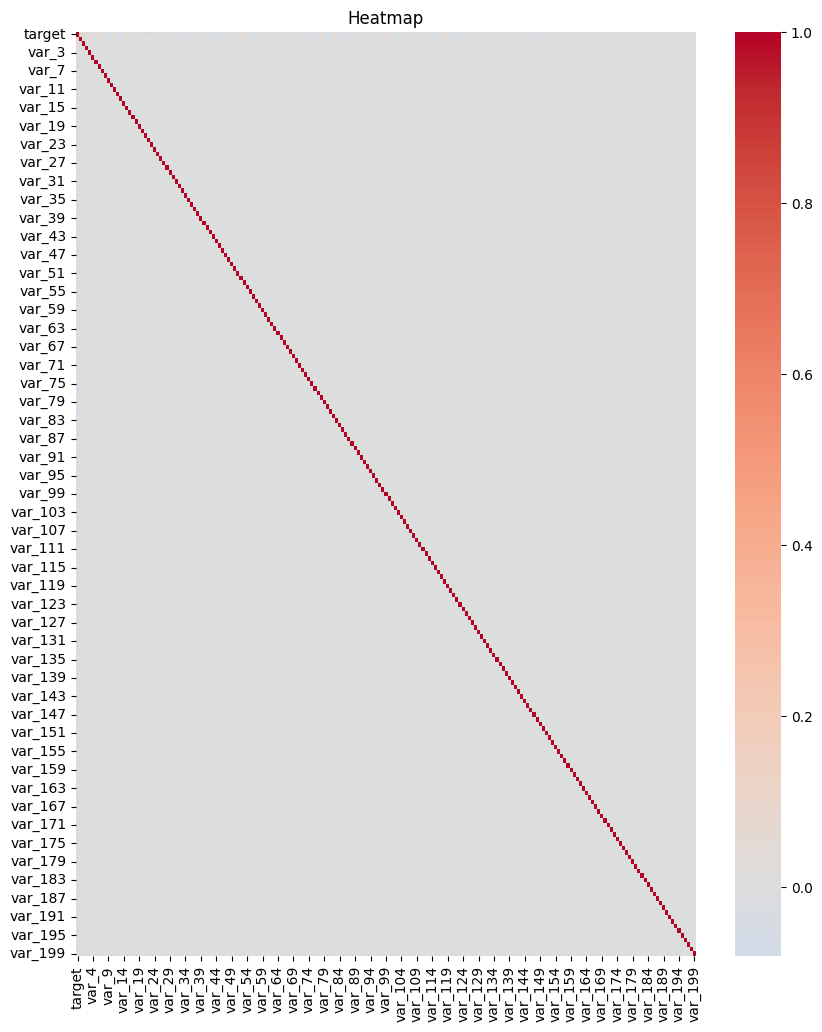

In [ ]:
corr = train.corr()
plt.figure(figsize=(10, 12))
plt.title('Heatmap')
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

As we can see that features are highly uncorrelated

Scaling features for PCA

In [ ]:
x = train.drop(columns=['target'])
y = train['target']

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA()
x_pca = pca.fit_transform(x_scaled)

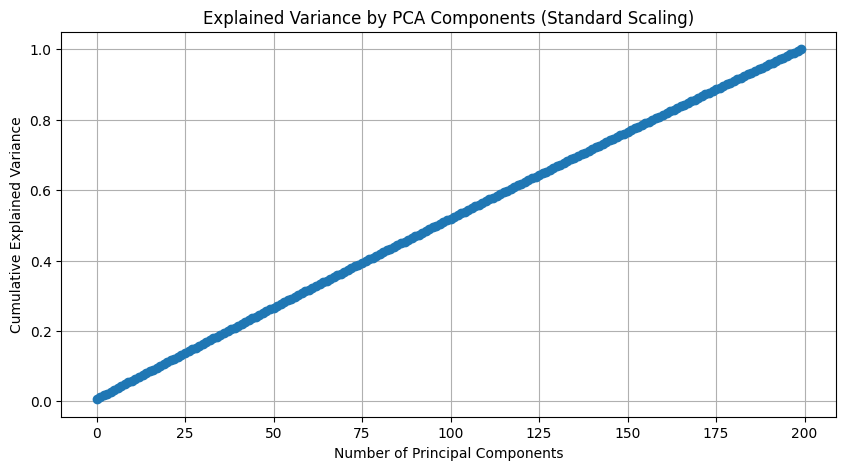

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.title('Explained Variance by PCA Components (Standard Scaling)')
plt.show()

Trying robust scaling

In [ ]:
robust = RobustScaler()
x_robust = robust.fit_transform(x)

x_pca_robust = pca.fit_transform(x_robust)

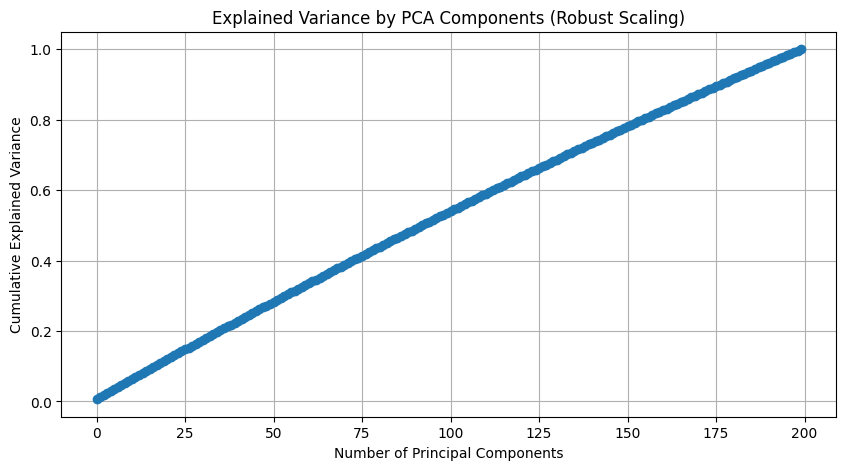

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.title('Explained Variance by PCA Components (Robust Scaling)')
plt.show()

As we can see PCA is not helping in dimensionality reduction because the features are mostly uncorrelated as we see in the heat map above, and the explained variance was evenly distributed across all components.


So we need to try other methods of dimensionality reduction like t-SNE and UMAP.

### t-SNE vs UMAP

Taking a sample of data for faster processing

In [ ]:
temp_idx = np.random.choice(len(x_scaled), size=10000, replace=False)
x_sample = x_scaled[temp_idx]
y_sample = y[temp_idx]

In [ ]:
x_sample

array([[ 0.64919645, -1.5497842 , -1.3855159 , ...,  1.061868  ,
         1.7036818 ,  0.961089  ],
       [-0.10480567, -1.6610425 ,  0.9887615 , ...,  0.4860364 ,
         1.0941703 ,  0.89929557],
       [ 0.89284456,  0.37595284,  1.0611615 , ..., -0.6546685 ,
        -0.5175199 ,  1.1972744 ],
       ...,
       [-1.2683419 ,  2.0334697 ,  0.6690962 , ...,  0.19025372,
        -0.75452244,  0.8196346 ],
       [-0.70364594, -0.03483386,  0.02881909, ..., -0.20589508,
        -0.32193312,  0.6607726 ],
       [ 1.0104086 ,  1.0921443 ,  0.49339777, ..., -0.5361824 ,
         0.93890357, -1.3236806 ]], dtype=float32)

t-SNE

In [ ]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
x_tsne = tsne.fit_transform(x_sample)

UMAP

In [ ]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
x_umap = umap_model.fit_transform(x_sample)

Plotting the graph of t-SNE and UMAP

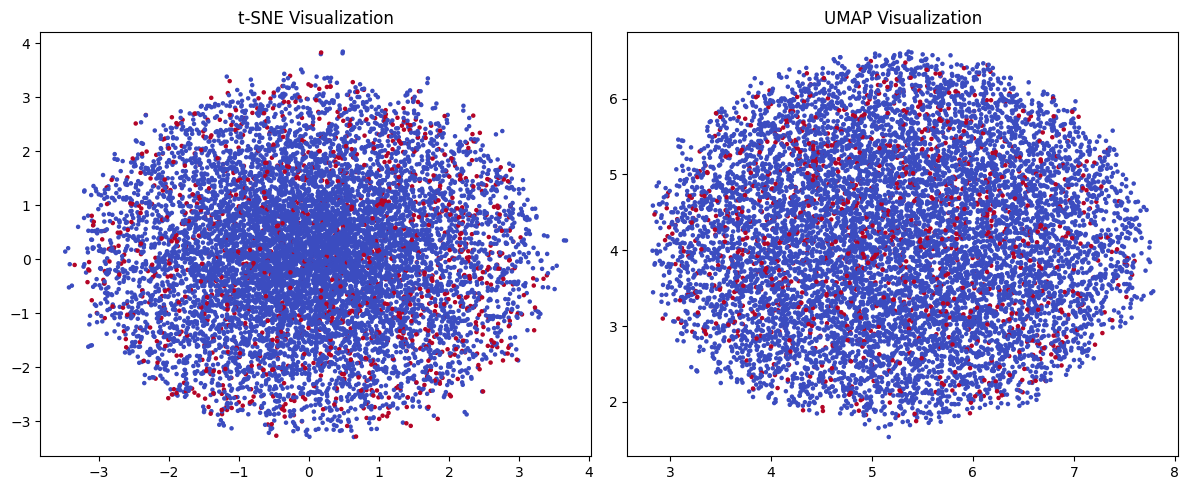

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(x_tsne[:,0], x_tsne[:,1], c=y_sample, cmap='coolwarm', s=5)
ax[0].set_title('t-SNE Visualization')
ax[1].scatter(x_umap[:,0], x_umap[:,1], c=y_sample, cmap='coolwarm', s=5)
ax[1].set_title('UMAP Visualization')
plt.tight_layout()
plt.show()


After exploring data we can say that:
1. The target column is highly unbalanced (almost 90% is '0' and only 10% is '1').
2. Correlation between features are very low (max is aprrox. 0.08).
3. PCA, t-SNE and UMAP are also unable to find any low-dimensional structre.

Therefore we have to rely on **non-linear algorithms** (like tree based or ensemble models) and **feature importance** analysis.

#### Train-Test-Split

In [ ]:
x = train.drop(columns=['target'])
y = train['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Since the target column is highly unbalanced we have to use `stratify=y`

In [ ]:
y_train.value_counts()

,count
target,
0,143922
1,16078


### Model Building

Adding `task_type='GPU'`, `device='cuda'` and `device='gpu'` in CatBoost, XGB and LGBM respectively so that we can use GPU for faster training.

In [ ]:
cat = CatBoostClassifier(task_type='GPU', iterations=1000, learning_rate=0.05, depth=8, eval_metric='AUC', random_state=42, verbose=0, auto_class_weights='Balanced')
xgb = XGBClassifier(n_estimators=1000, max_depth=6, random_state=42, n_jobs=-1, scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])), device='cuda')
lgb = LGBMClassifier(n_estimators=1000, max_depth=-1, random_state=42, class_weight='balanced', n_jobs=-1, verbosity=-1, device_type='gpu')

CatBoostClassifier

In [ ]:
cat_model = cat.fit(x_train, y_train)

Default metric period is 5 because AUC is/are not implemented for GPU


XGBClassifier

In [ ]:
xgb_model = xgb.fit(x_train, y_train)

LGBMClassifier

In [ ]:
lgb_model = lgb.fit(x_train, y_train)

Prediction

In [ ]:
y_pred_cat = cat_model.predict(x_test)
y_pred_xgb = xgb_model.predict(x_test)
y_pred_lgb = lgb_model.predict(x_test)

In [ ]:
print("CatBoost")
print(classification_report(y_test, y_pred_cat))
print("ROC: ", roc_auc_score(y_test, cat_model.predict_proba(x_test)[:, 1]))
print()

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC: ", roc_auc_score(y_test, xgb_model.predict_proba(x_test)[:, 1]))
print()

print("LightGBM")
print(classification_report(y_test, y_pred_lgb))
print("ROC: ", roc_auc_score(y_test, lgb_model.predict_proba(x_test)[:, 1]))

CatBoost
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     35980
           1       0.43      0.69      0.53      4020

    accuracy                           0.88     40000
   macro avg       0.69      0.79      0.73     40000
weighted avg       0.91      0.88      0.89     40000

ROC:  0.8905719042364608

XGBoost
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     35980
           1       0.62      0.36      0.46      4020

    accuracy                           0.91     40000
   macro avg       0.78      0.67      0.71     40000
weighted avg       0.90      0.91      0.90     40000

ROC:  0.8644601374727253

LightGBM
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     35980
           1       0.50      0.58      0.54      4020

    accuracy                           0.90     40000
   macro avg       0.73      0.76      0.74     40

Plotting bargraph of top 20 most important features

### Hyperparameter Tuning

CatBoost

In [ ]:
def objective_catboost(trial):
    params = {
        "iterations": 3000,  # upper limit; early stopping will stop earlier
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        "depth": trial.suggest_int("depth", 6, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.1, 5.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.5, 3.0, log=True),
        "border_count": trial.suggest_int("border_count", 64, 254),
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"]),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 4, 10),  # your imbalance ratio
        "eval_metric": "AUC",
        "task_type": "GPU",
        "verbose": False,
        "random_seed": 42,
    }


    if params["bootstrap_type"] == "Bayesian":
      params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 1.0)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(x_train, y_train):
        x_tr, x_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(
            x_tr, y_tr,
            eval_set=(x_val, y_val),
            early_stopping_rounds=100,
            verbose=False
        )

        preds = model.predict_proba(x_val)[:, 1]
        auc = roc_auc_score(y_val, preds)
        aucs.append(auc)

    return np.mean(aucs)

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_catboost, n_trials=25, show_progress_bar=True)

[I 2025-10-20 04:26:44,836] A new study created in memory with name: no-name-1df8e62f-1537-4331-9632-0db674333f1c


In [ ]:
print("Best CatBoost AUC:", study_cat.best_value)
print("Best CatBoost Params:", study_cat.best_params)

Best CatBoost AUC: 0.8878585667626561
Best CatBoost Params: {'learning_rate': 0.06899596883501909, 'depth': 9, 'l2_leaf_reg': 3.046949202715787, 'random_strength': 2.6035395860367343, 'border_count': 177, 'grow_policy': 'Depthwise', 'bootstrap_type': 'Bernoulli', 'scale_pos_weight': 6.0690858944877535}


As we can see that the CatBoost's base model is giving better AUC than the hyperparameter tuned model so we're gonna use the base model and use the best features for final model training.

XGBoost

In [ ]:
def objective_xgb(trial):
    params = {
    "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
    "max_depth": trial.suggest_int("max_depth", 3, 10),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    "gamma": trial.suggest_float("gamma", 0, 10),
    "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
    "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5.0, 10.0),
    "tree_method": "gpu_hist",
    "predictor": "gpu_predictor",
    "random_state": 42,
    "device": "cuda",
    "early_stopping_rounds": 50
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(x_train, y_train):
        x_tr, x_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**params, use_label_encoder=False)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(x_val)[:, 1]
        auc = roc_auc_score(y_val, preds)
        aucs.append(auc)

    return np.mean(aucs)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=25, show_progress_bar=True)

[I 2025-10-20 04:48:17,596] A new study created in memory with name: no-name-23bea9ec-acf9-4822-b269-17e2eaff55af


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-20 04:48:58,342] Trial 0 finished with value: 0.8653437508385203 and parameters: {'n_estimators': 1383, 'max_depth': 6, 'learning_rate': 0.17153916870981378, 'subsample': 0.730187050541667, 'colsample_bytree': 0.9600275157876454, 'gamma': 3.0064023763513026, 'min_child_weight': 3.673977310407602, 'reg_lambda': 0.016941783060333285, 'scale_pos_weight': 8.03634516529953}. Best is trial 0 with value: 0.8653437508385203.
[I 2025-10-20 04:49:51,255] Trial 1 finished with value: 0.8834020663670987 and parameters: {'n_estimators': 1097, 'max_depth': 6, 'learning_rate': 0.026269813203254992, 'subsample': 0.8709756629103989, 'colsample_bytree': 0.6056074753082298, 'gamma': 0.7956430153814975, 'min_child_weight': 1.9898475281642078, 'reg_lambda': 0.01722476568464111, 'scale_pos_weight': 7.877785546147458}. Best is trial 1 with value: 0.8834020663670987.
[I 2025-10-20 04:50:49,876] Trial 2 finished with value: 0.8797357203363311 and parameters: {'n_estimators': 1476, 'max_depth': 6, 'l

In [ ]:
print("Best XGBoost AUC:", study_xgb.best_value)
print("Best XGBoost Params:", study_xgb.best_params)

Best CatBoost AUC: 0.8945014561391226
Best CatBoost Params: {'n_estimators': 2000, 'max_depth': 3, 'learning_rate': 0.03884883329177226, 'subsample': 0.6024681028199645, 'colsample_bytree': 0.8796464980820777, 'gamma': 2.639173255106884, 'min_child_weight': 6.925151921905417, 'reg_lambda': 0.8443077890061993, 'scale_pos_weight': 5.3597978122512195}


As we can see that the hyperparameter tuned model of XGBoost is performing very good as compared to the base model so we'll use this model and check the important features.

LightGBM

In [ ]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 256),
        "max_depth": trial.suggest_int("max_depth", -1, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5.0, 10.0),
        "device_type": "gpu",
        "objective": "binary",
        "metric": "auc",
        "random_state": 42,
        "verbosity": -1,
        "early_stopping_rounds": 50,
        "n_jobs": -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(x_train, y_train):
        x_tr, x_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_val, y_val)],
            eval_metric="auc"
        )

        preds = model.predict_proba(x_val)[:, 1]
        auc = roc_auc_score(y_val, preds)
        aucs.append(auc)

    return np.mean(aucs)

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective_lgb, n_trials=25, show_progress_bar=True)

[I 2025-10-21 10:06:58,024] A new study created in memory with name: no-name-87aba4bb-cfd7-4804-bf98-bc02025cdf8d


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-10-21 10:08:25,574] Trial 0 finished with value: 0.8617500665850573 and parameters: {'n_estimators': 1344, 'learning_rate': 0.013481444359732654, 'num_leaves': 119, 'max_depth': 3, 'min_child_samples': 89, 'subsample': 0.6712515982811679, 'colsample_bytree': 0.7835605589938553, 'reg_alpha': 0.046533663967339906, 'reg_lambda': 0.027004538426271728, 'scale_pos_weight': 7.100726068136819}. Best is trial 0 with value: 0.8617500665850573.
[I 2025-10-21 10:11:17,070] Trial 1 finished with value: 0.8861040729194639 and parameters: {'n_estimators': 1221, 'learning_rate': 0.027281340672357476, 'num_leaves': 141, 'max_depth': 6, 'min_child_samples': 70, 'subsample': 0.690193882226768, 'colsample_bytree': 0.6116243895005259, 'reg_alpha': 0.1827182675854045, 'reg_lambda': 0.0206433210410909, 'scale_pos_weight': 5.2850385248095435}. Best is trial 1 with value: 0.8861040729194639.
[I 2025-10-21 10:26:10,211] Trial 2 finished with value: 0.8916179143541347 and parameters: {'n_estimators': 176

In [ ]:
print("Best LGBM AUC:", study_lgb.best_value)
print("Best LGBM Params:", study_lgb.best_params)

Best LGBM AUC: 0.892878823737825
Best LGBM Params: {'n_estimators': 1989, 'learning_rate': 0.015231247303922774, 'num_leaves': 44, 'max_depth': 0, 'min_child_samples': 81, 'subsample': 0.770961572572122, 'colsample_bytree': 0.9977000690982992, 'reg_alpha': 3.657421025428129, 'reg_lambda': 5.836642211285794, 'scale_pos_weight': 9.93702865276957}


As we can see that the hyperparameter tuned model of LightGBM is performing very good as compared to the base model so we'll use this model and check the important features.

Checking if gpu is available or not, if yes then we'll use gpu otherwise we'll not.

In [ ]:
# checking if gpu is available
use_gpu = torch.cuda.is_available()

# Best params of XGBoost, LightGBM and CatBoost respectively
xgb_best_params = {'n_estimators': 2000,
                    'max_depth': 3,
                    'learning_rate': 0.03884883329177226,
                    'subsample': 0.6024681028199645,
                    'colsample_bytree': 0.8796464980820777,
                    'gamma': 2.639173255106884,
                    'min_child_weight': 6.925151921905417,
                    'reg_lambda': 0.8443077890061993,
                    'scale_pos_weight': 5.3597978122512195,
                    'use_label_encoder': False,
                    "random_state": 42,
                  }

lgb_best_params = {'n_estimators': 1989,
                   'learning_rate': 0.015231247303922774,
                   'num_leaves': 44,
                   'max_depth': 0,
                   'min_child_samples': 81,
                   'subsample': 0.770961572572122,
                   'colsample_bytree': 0.9977000690982992,
                   'reg_alpha': 3.657421025428129,
                   'reg_lambda': 5.836642211285794,
                   'scale_pos_weight': 9.93702865276957,
                   "objective": "binary",
                   "metric": "auc",
                   "random_state": 42,
                   "verbosity": -1,
                  }

cat_best_params = {"iterations": 1000,
                   "learning_rate": 0.05,
                   "depth": 8,
                   "eval_metric": 'AUC',
                   "random_state": 42,
                   "verbose": 0,
                   "auto_class_weights": 'Balanced'
                  }

# switching to gpu/cpu according to availability
if use_gpu:
  xgb_best_params.update({"tree_method": "gpu_hist",
                            "predictor": "gpu_predictor",
                            "device": "cuda"
                          })
  lgb_best_params["device_type"] = "gpu"
  cat_best_params["task_type"] = "GPU"
else:
  xgb_best_params["n_jobs"] = -1
  lgb_best_params["n_jobs"] = -1

In [ ]:
best_xgb = XGBClassifier(**xgb_best_params)
best_lgb = LGBMClassifier(**lgb_best_params)
best_cat = cat = CatBoostClassifier(**cat_best_params)

In [ ]:
# best XGBoost
best_xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8796464980820777, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=2.639173255106884, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03884883329177226,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=6.925151921905417, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# best LightGBM
best_lgb.fit(x_train, y_train)

LGBMClassifier(colsample_bytree=0.9977000690982992,
               learning_rate=0.015231247303922774, max_depth=0, metric='auc',
               min_child_samples=81, n_estimators=1989, n_jobs=-1,
               num_leaves=44, objective='binary', random_state=42,
               reg_alpha=3.657421025428129, reg_lambda=5.836642211285794,
               scale_pos_weight=9.93702865276957, subsample=0.770961572572122,
               verbosity=-1)

In [ ]:
# best CatBoost
best_cat.fit(x_train, y_train)

In [ ]:
# checking performance of models with the best parameters
models = {
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "CatBoost": best_cat
}

for name, model in models.items():
  y_pred = model.predict(x_test)
  y_proba = model.predict_proba(x_test)[:, 1]

  print(name)
  print(classification_report(y_test, y_pred))
  print("ROC: ", roc_auc_score(y_test, y_proba))
  print()

XGBoost
              precision    recall  f1-score   support

           0       0.96      0.92      0.94     35980
           1       0.48      0.65      0.55      4020

    accuracy                           0.89     40000
   macro avg       0.72      0.79      0.75     40000
weighted avg       0.91      0.89      0.90     40000

ROC:  0.8947935869568223

LightGBM
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     35980
           1       0.41      0.72      0.52      4020

    accuracy                           0.87     40000
   macro avg       0.69      0.80      0.72     40000
weighted avg       0.91      0.87      0.88     40000

ROC:  0.8925092298374719

CatBoost
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     35980
           1       0.43      0.69      0.53      4020

    accuracy                           0.88     40000
   macro avg       0.69      0.79      0.73     40

As we can see the model is performing good. We should now check the most important features which are being used in training the model so that we can make the models even more accurate.

In [ ]:
# Getting important features
feat_imp_cat = pd.Series(best_cat.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feat_imp_xgb = pd.Series(best_xgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feat_imp_lgb = pd.Series(best_lgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)

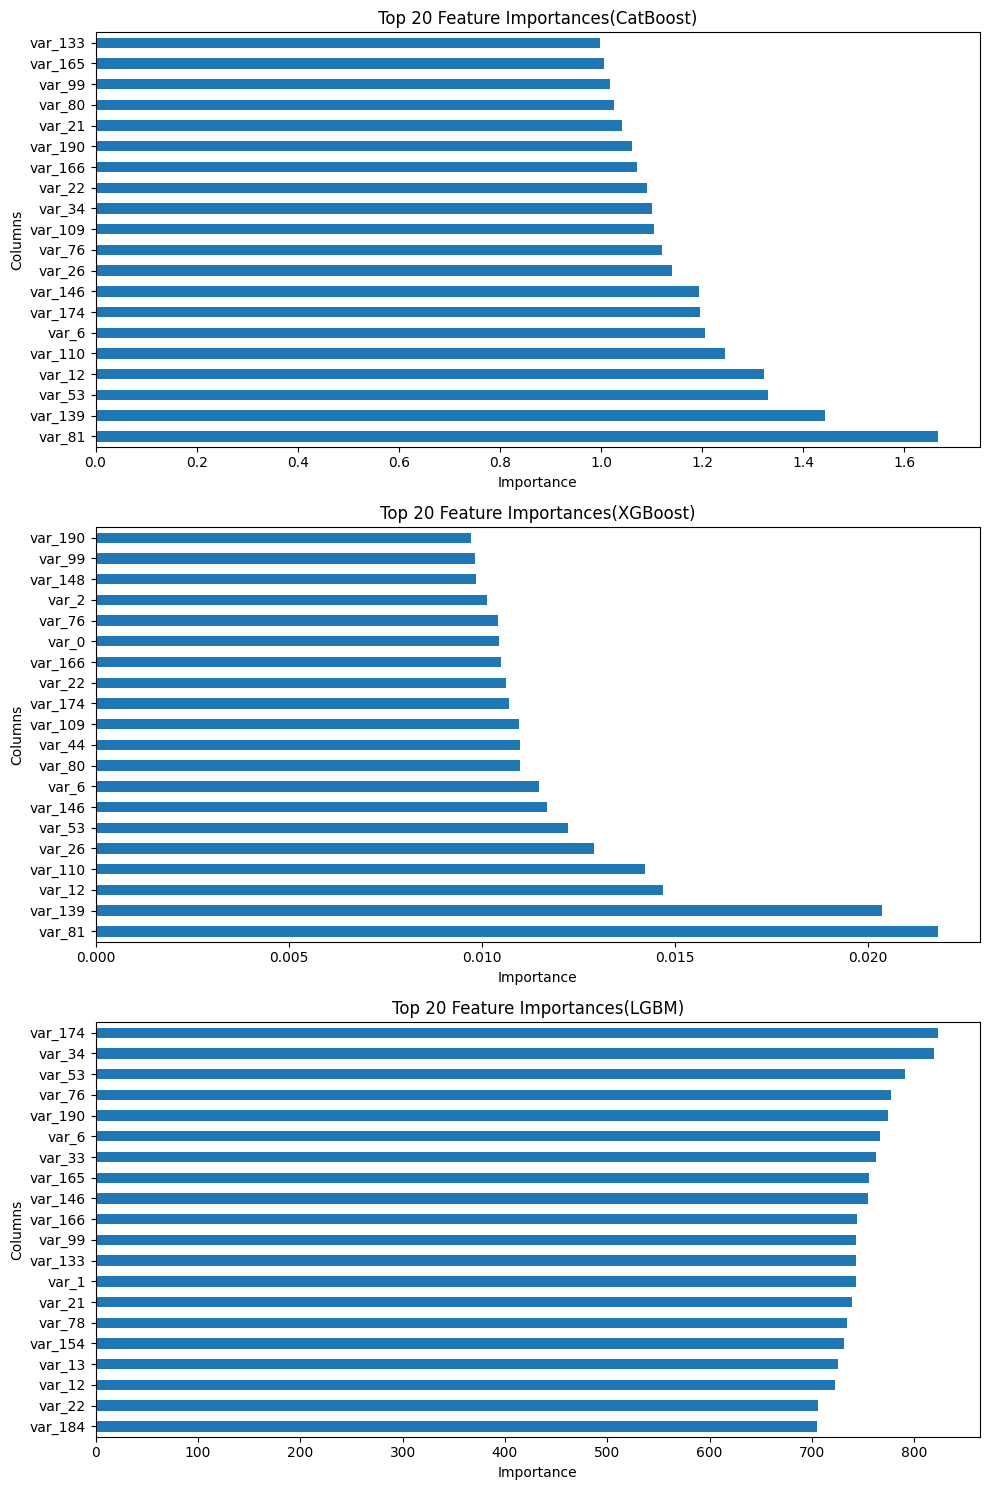

In [ ]:
# plotting best features
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

feat_imp_cat.head(20).plot(kind='barh', ax=ax[0])
ax[0].set_title('Top 20 Feature Importances(CatBoost)')
ax[0].set_xlabel('Importance')
ax[0].set_ylabel('Columns')

feat_imp_xgb.head(20).plot(kind='barh', ax=ax[1])
ax[1].set_title('Top 20 Feature Importances(XGBoost)')
ax[1].set_xlabel('Importance')
ax[1].set_ylabel('Columns')

feat_imp_lgb.head(20).plot(kind='barh', ax=ax[2])
ax[2].set_title('Top 20 Feature Importances(LGBM)')
ax[2].set_xlabel('Importance')
ax[2].set_ylabel('Columns')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Common important features in the models
top_features_cat = set(feat_imp_cat.head(30).index)
top_features_xgb = set(feat_imp_xgb.head(30).index)
top_features_lgb = set(feat_imp_lgb.head(30).index)

common = top_features_cat & top_features_xgb & top_features_lgb
print("Common important features across all the models: ", common)

We found 16 features which are important to all three models(CatBoost, XGBoost and LightGBM).

Now we're gonna check if they are improving the model's performance or not.

In [ ]:
important_features = ['var_99', 'var_78', 'var_166', 'var_146', 'var_22', 'var_6',
                      'var_21', 'var_110', 'var_133', 'var_174', 'var_76', 'var_13',
                      'var_190', 'var_53', 'var_109', 'var_12'
                     ]
x_train_reduced = x_train[important_features]
x_test_reduced = x_test[important_features]

In [ ]:
x_train_reduced.head()

,var_99,var_78,var_166,var_146,var_22,var_6,var_21,var_110,var_133,var_174,var_76,var_13,var_190,var_53,var_109,var_12
172692,-3.0228,1.9631,3.4186,9.6965,-0.3950,5.1426,28.893101,5.8836,7.6618,17.655100,10.2909,13.0615,-2.8810,6.7444,18.749599,14.0022
123366,3.0000,3.5042,2.9240,13.0205,-0.8828,4.2671,11.288800,2.3799,6.1839,31.921801,15.8732,3.4091,0.2397,6.5631,13.232300,14.0069
6709,-5.2426,7.5628,2.3378,7.1425,2.0789,5.1010,32.083401,9.1060,6.9928,22.287800,-8.4509,5.0833,8.1638,6.0164,24.707600,14.3897
30154,-1.3632,5.7130,2.5813,3.9650,7.4205,6.7299,21.441601,3.0113,6.9221,13.907900,-0.5282,7.4468,9.3914,6.5012,24.626600,13.8234
181706,1.1190,7.6323,2.7444,7.6441,5.4634,4.7486,26.521299,4.9983,6.7985,26.861401,4.5236,5.3546,8.4802,6.1231,13.955100,14.0785


In [ ]:
# training the model and checking roc
# models = {
#     "XGBoost": best_xgb,
#     "LightGBM": best_lgb,
#     "CatBoost": best_cat
# }
for name, model in models.items():
  print(name)
  model.fit(x_train_reduced, y_train)
  y_pred = model.predict(x_test_reduced)
  y_proba = model.predict_proba(x_test_reduced)[:, 1]
  print(classification_report(y_test, y_pred))
  print("ROC: ", roc_auc_score(y_test, y_proba))
  print()

XGBoost
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     35980
           1       0.27      0.42      0.33      4020

    accuracy                           0.82     40000
   macro avg       0.60      0.65      0.61     40000
weighted avg       0.86      0.82      0.84     40000

ROC:  0.7301296740311781

LightGBM
              precision    recall  f1-score   support

           0       0.94      0.73      0.82     35980
           1       0.20      0.60      0.30      4020

    accuracy                           0.72     40000
   macro avg       0.57      0.66      0.56     40000
weighted avg       0.87      0.72      0.77     40000

ROC:  0.7242489055556016

CatBoost
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     35980
           1       0.23      0.51      0.31      4020

    accuracy                           0.78     40000
   macro avg       0.58      0.66      0.59     40

As we can see that selecting common features only not helping with the model's performance.
This time we'll try selecting all the top 30 importance features of all the 3 models, i.e. taking the union instead intersection.

In [ ]:
top = 50

top_features_cat = feat_imp_cat.nlargest(top).index
top_features_xgb = feat_imp_xgb.nlargest(top).index
top_features_lgb = feat_imp_lgb.nlargest(top).index

top_features = set(top_features_cat) | set(top_features_xgb) | set(top_features_lgb)
len(top_features)

58

In [ ]:
top_features = list(top_features)

x_train_reduced = x_train[top_features]
x_test_reduced = x_test[top_features]

In [ ]:
x_train_reduced

,var_0,var_148,var_170,var_9,var_76,var_13,var_115,var_109,var_107,var_94,...,var_169,var_2,var_26,var_121,var_122,var_177,var_190,var_53,var_22,var_149
172692,15.4140,4.1204,-10.0089,8.6555,10.2909,13.0615,2.6428,18.749599,13.1775,11.0412,...,5.5012,10.4773,1.2336,8.1747,1.5540,9.335100,-2.8810,6.7444,-0.3950,5.1653
123366,12.3576,4.1217,-4.8115,4.8252,15.8732,3.4091,1.3750,13.232300,28.2239,13.1765,...,6.0900,11.7785,-4.4422,10.1097,-6.0629,10.550200,0.2397,6.5631,-0.8828,11.4715
6709,9.4142,4.2034,-1.9245,9.5959,-8.4509,5.0833,4.4470,24.707600,22.5278,8.7044,...,5.6965,7.2196,-3.8679,13.5527,0.7437,7.834700,8.1638,6.0164,2.0789,0.0642
30154,13.0647,4.0448,3.1334,8.6047,-0.5282,7.4468,4.5593,24.626600,18.3263,16.8256,...,6.1160,13.0270,-18.5741,14.7015,-5.3460,8.671900,9.3914,6.5012,7.4205,3.8922
181706,9.5222,4.0329,-5.1867,6.3487,4.5236,5.3546,1.1448,13.955100,22.1266,5.9288,...,4.7693,8.2173,1.3145,10.4676,-5.3447,12.542600,8.4802,6.1231,5.4634,2.0326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160482,8.0801,3.9341,1.1235,7.8673,7.6959,13.0744,2.4833,19.435499,14.9818,10.4982,...,6.0160,10.6587,-10.1357,11.2822,6.2368,12.425600,4.9773,5.9731,2.0442,20.5940
48966,11.8371,3.8863,-1.0223,7.5124,12.0833,5.8174,1.1526,15.237400,27.7001,14.0438,...,6.3410,12.9172,-11.5659,13.6410,10.0985,16.017599,2.3344,6.5942,-0.8335,3.3211
52242,11.3368,3.6179,-0.4619,5.9524,6.3644,8.0443,1.6428,15.679000,27.6660,11.2924,...,5.0023,14.1568,10.2604,13.4050,3.2274,8.358700,5.7440,4.8170,4.2183,11.4608
7767,3.4660,4.0553,-2.1186,8.7558,-4.1018,14.8093,7.4557,21.404699,8.2138,8.3197,...,5.3449,4.3530,-3.2855,11.0711,7.8149,9.601700,2.3471,6.8166,5.2162,-0.2043


In [ ]:
# training the model and checking roc
# models = {
#     "XGBoost": best_xgb,
#     "LightGBM": best_lgb,
#     "CatBoost": best_cat
# }
for name, model in models.items():
  print(name)
  model.fit(x_train_reduced, y_train)
  y_pred = model.predict(x_test_reduced)
  y_proba = model.predict_proba(x_test_reduced)[:, 1]
  print(classification_report(y_test, y_pred))
  print("ROC: ", roc_auc_score(y_test, y_proba))
  print()

XGBoost
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     35980
           1       0.39      0.61      0.48      4020

    accuracy                           0.86     40000
   macro avg       0.67      0.75      0.70     40000
weighted avg       0.90      0.86      0.88     40000

ROC:  0.8546500543419644

LightGBM
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     35980
           1       0.32      0.70      0.44      4020

    accuracy                           0.82     40000
   macro avg       0.64      0.77      0.66     40000
weighted avg       0.90      0.82      0.85     40000

ROC:  0.8511403170362749

CatBoost
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     35980
           1       0.35      0.64      0.45      4020

    accuracy                           0.84     40000
   macro avg       0.65      0.76      0.68     40

In [ ]:
# models
models = {
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "CatBoost": best_cat
}

# selecting top 75 and 100 features in all three models (union) and checking performance
for n in [75, 100]:
  top_features_cat = feat_imp_cat.nlargest(n).index
  top_features_xgb = feat_imp_xgb.nlargest(n).index
  top_features_lgb = feat_imp_lgb.nlargest(n).index

  top_features = list(set(top_features_cat) | set(top_features_xgb) | set(top_features_lgb))

  print(n, ":", len(top_features), "features")

  x_train_reduced = x_train[top_features]
  x_test_reduced = x_test[top_features]

  for name, model in models.items():
    print(name)
    model.fit(x_train_reduced, y_train)
    y_pred = model.predict(x_test_reduced)
    y_proba = model.predict_proba(x_test_reduced)[:, 1]
    print(classification_report(y_test, y_pred))
    print("ROC: ", roc_auc_score(y_test, y_proba))
    print()

75 : 82 features
XGBoost
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     35980
           1       0.42      0.64      0.51      4020

    accuracy                           0.88     40000
   macro avg       0.69      0.77      0.72     40000
weighted avg       0.90      0.88      0.89     40000

ROC:  0.8755192353961154

LightGBM
              precision    recall  f1-score   support

           0       0.96      0.85      0.91     35980
           1       0.35      0.72      0.47      4020

    accuracy                           0.84     40000
   macro avg       0.66      0.79      0.69     40000
weighted avg       0.90      0.84      0.86     40000

ROC:  0.8724325081098123

CatBoost


Default metric period is 5 because AUC is/are not implemented for GPU


              precision    recall  f1-score   support

           0       0.96      0.88      0.92     35980
           1       0.38      0.68      0.48      4020

    accuracy                           0.86     40000
   macro avg       0.67      0.78      0.70     40000
weighted avg       0.90      0.86      0.87     40000

ROC:  0.8705995591801968

100 : 109 features
XGBoost
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     35980
           1       0.45      0.65      0.54      4020

    accuracy                           0.89     40000
   macro avg       0.71      0.78      0.74     40000
weighted avg       0.91      0.89      0.89     40000

ROC:  0.8877472006283202

LightGBM
              precision    recall  f1-score   support

           0       0.97      0.87      0.91     35980
           1       0.38      0.72      0.50      4020

    accuracy                           0.85     40000
   macro avg       0.67      0.80      0

Default metric period is 5 because AUC is/are not implemented for GPU


              precision    recall  f1-score   support

           0       0.96      0.89      0.92     35980
           1       0.41      0.70      0.52      4020

    accuracy                           0.87     40000
   macro avg       0.69      0.79      0.72     40000
weighted avg       0.91      0.87      0.88     40000

ROC:  0.8851392910378624



Model with 109 features are performing almost similar to models with all 200 columns, so now we'll try ensembling them and see if that improves the performance more or not.

In [ ]:
# saving prediction of each models
cat_preds = best_cat.predict_proba(x_test[top_features])[:, 1]
xgb_preds = best_xgb.predict_proba(x_test[top_features])[:, 1]
lgb_preds = best_lgb.predict_proba(x_test[top_features])[:, 1]

Simple Averaging

In [ ]:
sim_avg_pred = (cat_preds + xgb_preds + lgb_preds) / 3
print(roc_auc_score(y_test, sim_avg_pred))

0.8882808165951787


Weighted Averaging

In [ ]:
wei_avg_pred = (
    0.5 * cat_preds +
    0.35 * xgb_preds +
    0.4 * lgb_preds
)

print(roc_auc_score(y_test, wei_avg_pred))

0.8882130827242332


Stacking (Meta Model)

In [ ]:
top = 100

top_features_cat = feat_imp_cat.nlargest(top).index
top_features_xgb = feat_imp_xgb.nlargest(top).index
top_features_lgb = feat_imp_lgb.nlargest(top).index

top_features = list(set(top_features_cat) | set(top_features_xgb) | set(top_features_lgb))
print(len(top_features))

x_train_reduced = x_train[top_features]
x_test_reduced = x_test[top_features]

109


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# storing out-of-fold(oof) predictions for meta training
oof_meta = np.zeros((len(x_train_reduced), 3))
test_meta = np.zeros((len(x_test_reduced), 3))

for fold, (train_idx, test_idx) in enumerate(cv.split(x_train_reduced, y_train)):
    print(f"Fold {fold+1}/{cv.n_splits}")
    x_tr, x_val = x_train_reduced.iloc[train_idx], x_train_reduced.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # training base models on folds
    cat_model = CatBoostClassifier(**cat_best_params)
    xgb_model = XGBClassifier(**xgb_best_params)
    lgb_model = LGBMClassifier(**lgb_best_params)

    cat_model.fit(x_tr, y_tr)
    xgb_model.fit(x_tr, y_tr)
    lgb_model.fit(x_tr, y_tr)

    # predictions on validation fold
    oof_meta[test_idx, 0] = cat_model.predict_proba(x_val)[:, 1]
    oof_meta[test_idx, 1] = xgb_model.predict_proba(x_val)[:, 1]
    oof_meta[test_idx, 2] = lgb_model.predict_proba(x_val)[:, 1]

    # predictions on hold-out validation set for final meta test
    test_meta[:, 0] += cat_model.predict_proba(x_test_reduced)[:, 1] / cv.n_splits
    test_meta[:, 1] += xgb_model.predict_proba(x_test_reduced)[:, 1] / cv.n_splits
    test_meta[:, 2] += lgb_model.predict_proba(x_test_reduced)[:, 1] / cv.n_splits


Fold 1/5


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2/5


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 3/5


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4/5


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5/5


Default metric period is 5 because AUC is/are not implemented for GPU


In [ ]:
# training meta model on OOF prediction with LogisticRegression
meta_model_lr = LogisticRegression(n_jobs=-1)
meta_model_lr.fit(oof_meta, y_train)

# Final Predictions
final_preds_lr = meta_model_lr.predict_proba(test_meta)[:, 1]
print(roc_auc_score(y_test, final_preds_lr))

0.8889693970392617


In [ ]:
print(classification_report(y_test, meta_model_lr.predict(test_meta)))
print(roc_auc_score(y_test, final_preds_lr))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     35980
           1       0.69      0.39      0.50      4020

    accuracy                           0.92     40000
   macro avg       0.81      0.69      0.73     40000
weighted avg       0.91      0.92      0.91     40000

0.8889693970392617


Trying stacking on models with all the 200 features

In [ ]:
cat_pred = best_cat.predict_proba(x_test)[:, 1]
xgb_pred = best_xgb.predict_proba(x_test)[:, 1]
lgb_pred = best_lgb.predict_proba(x_test)[:, 1]

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# storing out-of-fold(oof) predictions for meta training
oof_meta = np.zeros((len(x_train), 3))
test_meta = np.zeros((len(x_test), 3))

for fold, (train_idx, test_idx) in enumerate(cv.split(x_train, y_train)):
    print(f"Fold {fold+1}/{cv.n_splits}")
    x_tr, x_val = x_train.iloc[train_idx], x_train.iloc[test_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # training base models on folds
    cat_model = CatBoostClassifier(**cat_best_params)
    xgb_model = XGBClassifier(**xgb_best_params)
    lgb_model = LGBMClassifier(**lgb_best_params)

    cat_model.fit(x_tr, y_tr)
    xgb_model.fit(x_tr, y_tr)
    lgb_model.fit(x_tr, y_tr)

    # predictions on validation fold
    oof_meta[test_idx, 0] = cat_model.predict_proba(x_val)[:, 1]
    oof_meta[test_idx, 1] = xgb_model.predict_proba(x_val)[:, 1]
    oof_meta[test_idx, 2] = lgb_model.predict_proba(x_val)[:, 1]

    # predictions on hold-out validation set for final meta test
    test_meta[:, 0] += cat_model.predict_proba(x_test)[:, 1] / cv.n_splits
    test_meta[:, 1] += xgb_model.predict_proba(x_test)[:, 1] / cv.n_splits
    test_meta[:, 2] += lgb_model.predict_proba(x_test)[:, 1] / cv.n_splits

xgb_meta_model = XGBClassifier(random_state=42)
xgb_meta_model.fit(oof_meta, y_train)

lr_meta_model = LogisticRegression(n_jobs=-1, random_state=42)
lr_meta_model.fit(oof_meta, y_train)

xgb_meta_preds = xgb_meta_model.predict_proba(test_meta)[:, 1]
lr_meta_preds = lr_meta_model.predict_proba(test_meta)[:, 1]

print("ROC of XGB: ", roc_auc_score(y_test, xgb_meta_preds))
print("ROC of LR: ", roc_auc_score(y_test, lr_meta_preds))

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
ROC of XGB:  0.8937718024662679
ROC of LR:  0.8963503494202141


# Final Evaluation and Conclusion

## Model Performance Overview

After extensive experiment with CatBoost, XGBoost and LightGBM, inluding data preprocessing, feature selection and hyperparamter tuning with optuna we got the following ROC score:
1. CatBoost: 0.890
2. XGBoost: 0.892
3. LightGBM: 0.894
4. Stacking Ensemble
   (Logistic Regression Meta Model): 0.896

## Interpretation

* The dataset was highly imbalanced with ~10% positive samples.
* Individual models were performing really good but there was trade off between reall and precision for th minority class.
* The stacked model(Logistic Regression Meta model) combined the strength of all three models and make improved the ROC-AUC score.
* Feature Selectin was explored to reduce training time and analyzing feature selection. However, the final ensemble was trained on all of the features as this configuration yielded the strongest performance.


## Key Features

The following features were consistently identified as the important feature across multiple models, suggesting stronger predicive importnce:

`['var_99', 'var_78', 'var_166', 'var_146', 'var_22', 'var_6', 'var_21','var_110', 'var_133', 'var_174', 'var_76', 'var_13', 'var_190', 'var_53', 'var_109', 'var_12']`

## Conclusion

Through systematic experimentation, tuning and ensembling:
* Multiple boosting models (CatBoost, XGBoost and LightGBM) were tuned individually using optuna (GPU when available) on complete feature set.
* Their predictions were combined via stacking, thus have the strengths of each base models.
* The final ensemble achieved a ROC score of 0.896, strongest of all individual models.